In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

## Load data

In [ ]:
df = pd.read_csv("MMG_FARA_2019_county.csv", dtype={'FIPS': str})
df['FIPS'] = df['FIPS'].str.zfill(5)

counties = gpd.read_file('https://www2.census.gov/geo/tiger/GENZ2019/shp/cb_2019_us_county_20m.zip')
counties['FIPS'] = counties['STATEFP'] + counties['COUNTYFP']

contig = counties[~counties['STATEFP'].isin(['02', '15', '60', '66', '69', '72', '78'])]

gdf = contig.merge(df, on='FIPS', how='left').to_crs('ESRI:102003')

if 'LILATracts_1And10' in gdf.columns and 'n_tracts' in gdf.columns:
    gdf['lila_share'] = gdf['LILATracts_1And10'] / gdf['n_tracts']

/home/lily/Desktop/uiucCourses/IS477/finalProject/cloneFolder/Canaries/.venv/lib/python3.12/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


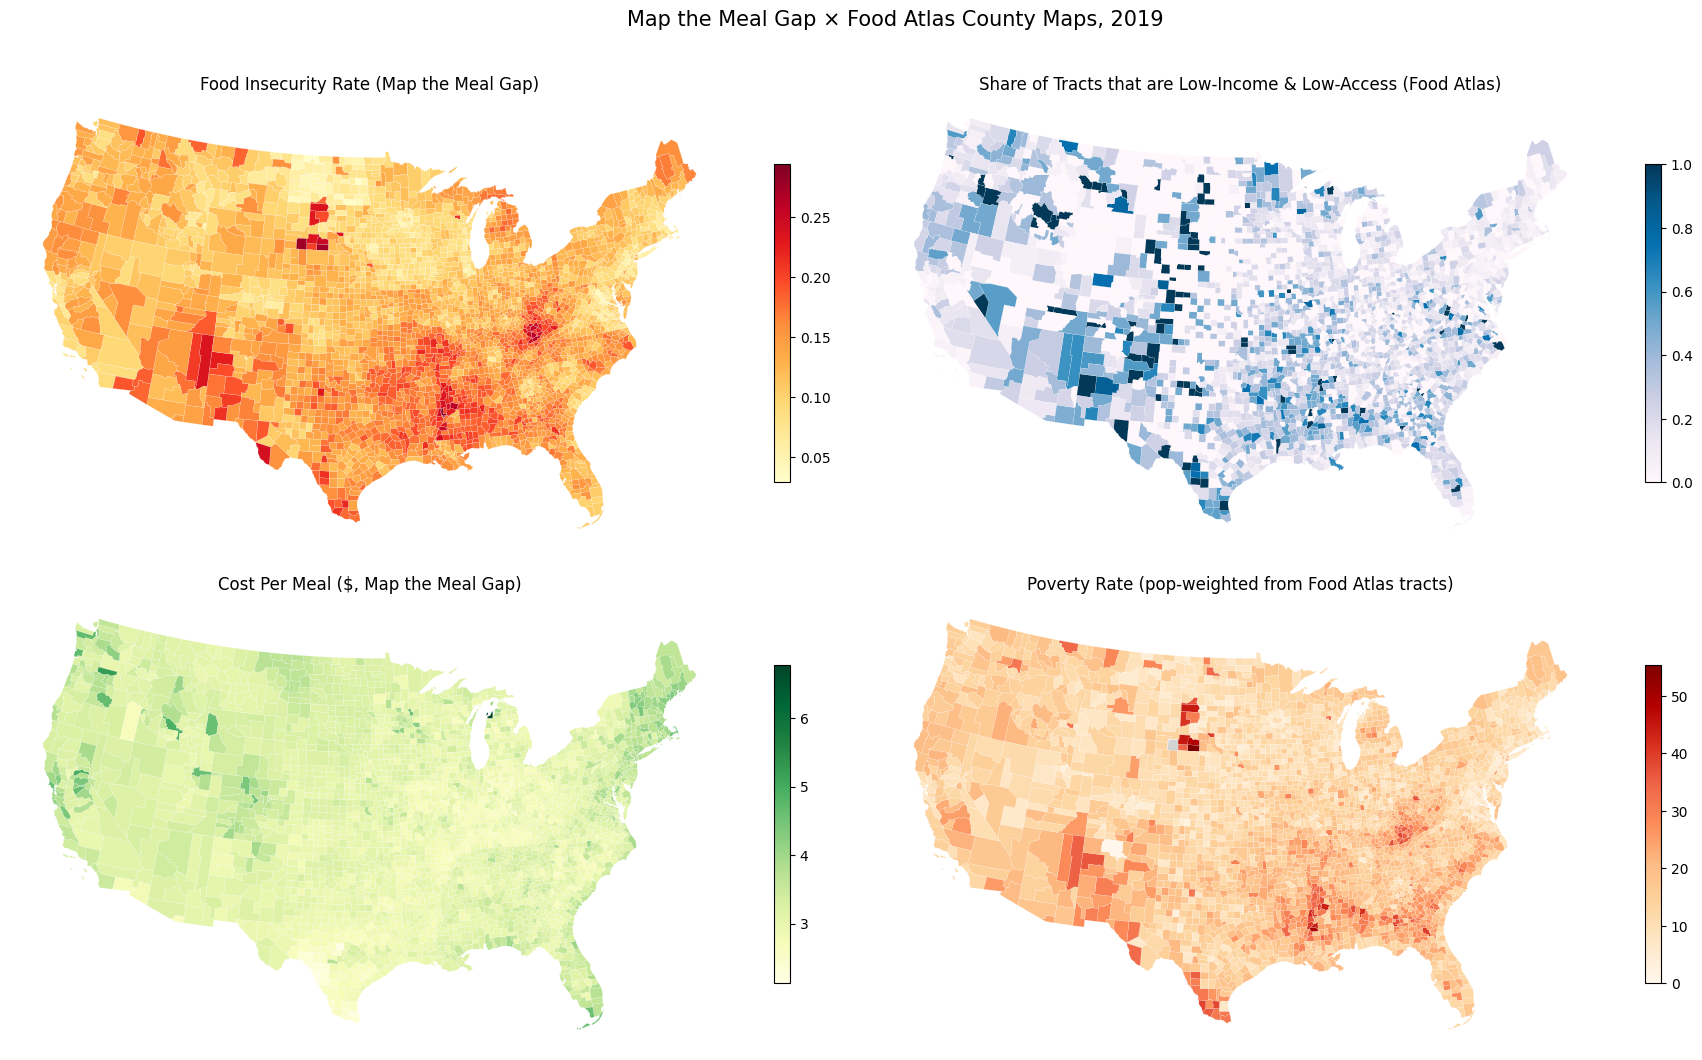

In [ ]:
maps = [
    ('pctFoodInsecure', 'Food Insecurity Rate (Map the Meal Gap)', 'YlOrRd'),
    ('lila_share',      'Share of Tracts that are Low-Income & Low-Access (Food Atlas)', 'PuBu'),
    ('costPerMeal',     'Cost Per Meal ($, Map the Meal Gap)', 'YlGn'),
    ('PovertyRate',     'Poverty Rate (pop-weighted from Food Atlas tracts)', 'OrRd'),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
for ax, (col, title, cmap) in zip(axes.flat, maps):
    if col not in gdf.columns:
        ax.set_visible(False)
        continue
    gdf.plot(
        column=col, ax=ax, cmap=cmap,
        legend=True, legend_kwds={'shrink': 0.6},
        missing_kwds={'color': 'lightgrey', 'label': 'No data'},
        edgecolor='white', linewidth=0.1,
    )
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.suptitle('Map the Meal Gap × Food Atlas County Maps, 2019', fontsize=15, y=0.995)
plt.tight_layout()
plt.savefig('mmg_fara_test_maps.png', dpi=150, bbox_inches='tight')
plt.show()